In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot  as plt

## Открытие датасета

In [ ]:
raw_df = pd.read_csv("C:\Users\levkn\OneDrive\Desktop\jupyter\shop\ifood_df.csv")
pd.set_option('display.max_columns', None)
raw_df.head()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (974170941.py, line 1)

## Описание данных

In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
# Проверка на повторяющиеся значения по ключевому столбцу ID 

raw_df.duplicated('ID').any()

False

### Выводы: 
1. Пропуски в данных: В поле Income обнаружено 24 незаполненных записи. Данный факт будет учитываться при интерпретации результатов, связанных с доходом клиентов.
2. Оптимизация признаков: Для повышения наглядности анализа предлагается провести замену абсолютных значений в колонке Year_Birth на рассчитанный возраст покупателей. Аналогично, вместо фиксированной даты в поле Dt_Customer (дата оформления первой покупки) более информативно использовать показатель "стаж клиента" (количество дней с момента регистрации).
3. Расчет совокупных метрик: Целесообразно дополнить таблицу новыми вычисляемыми полями:

        Общая сумма расходов клиента по всем продуктовым категориям (Mnt_Total).

        Суммарное количество маркетинговых кампаний, на которые откликнулся покупатель (Accepted_Total).

        Общее количество совершенных покупок (сумма покупок в канале, через веб-сайт, по каталогу и в магазине) (Purchases_Total).

4. Уникальность записей: Проверка показала отсутствие дублирующихся идентификаторов клиентов, что говорит о корректности структуры данных.


*** Типы данных в столбцах AcceptedCmp3-Complain и Response, согласно описанию данных, соответствуют boolean-значениям, но сейчас это целочисленные значения (int64). В отдельной ячейке будет прописан код для проведения данного преобразования, если таковое потребуется

In [ ]:
new_var = pd.DataFrame({'ID': raw_df['ID'],
                   'Age': (pd.to_datetime('now').year - raw_df['Year_Birth']), # подсчет возраста покупателей
                   'Days_as_cus': ((pd.to_datetime('now') - pd.to_datetime(raw_df['Dt_Customer'])) // pd.Timedelta(1, 'd')), # Подсчет количества дней с первого дня в качестве покупателя
                   'Mnt_Total': raw_df.loc[:,['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts']].sum(axis=1), # Подсчет общих затрат на все категории товаров 
                   'Accepted_Total': raw_df.loc[:,['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1), # подсчет общего числа одобрения рекламных компаний
                   'Purchases_Total': (raw_df['NumWebPurchases'] + raw_df['NumStorePurchases']), # подсчет общего числа совершенных покупок 
                   'Children_Total': raw_df.loc[:, ['Kidhome', 'Teenhome']].sum(axis=1) # подсчет общего количества детей в семье
                   })

df = new_var.merge(raw_df
                   .drop(['Year_Birth', 'Dt_Customer'], axis=1) # Удаление ненужных столбцов 
                   .dropna(), # Удаление строк с пропущенными значениями хоть в одном из столбцов
                   on='ID')
df.head()

,ID,Age,Days_as_cus,Mnt_Total,Accepted_Total,Purchases_Total,Children_Total,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,68,4576,1529,1,12,0,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,71,4026,21,0,3,2,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,60,4225,734,0,18,0,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,41,4052,48,0,6,1,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,44,4074,407,0,11,1,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
# ЗАПУСКАТЬ ЯЧЕЙКУ ПРИНЕОБХОДИМОСТИ!!!
# Приведение необходимых столбцов к формату boolean

#for column in df.columns[20:26]:
#    df[column] = df[column].astype(bool)

#df['Response'] = df['Response'].astype(bool)
#df.info()

## Проверка на ошибки

In [ ]:
# Общие траты не должны быть равны нулю (иначе покупатель ничего не покупал)

df[df['Mnt_Total'] == 0]

,ID,Age,Days_as_cus,Mnt_Total,Accepted_Total,Purchases_Total,Children_Total,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [ ]:
# Общее количество покупок также не должно быть равно нулю

df[df['Purchases_Total'] == 0]

,ID,Age,Days_as_cus,Mnt_Total,Accepted_Total,Purchases_Total,Children_Total,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
20,5376,46,4452,1729,0,0,1,Graduation,Married,2447.0,1,0,42,1,1,1725,1,1,1,15,0,28,0,1,0,0,0,0,0,0,3,11,0
153,8475,52,4033,1607,0,0,1,PhD,Married,157243.0,0,1,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,3,11,0
642,5555,50,4055,5,0,0,0,Graduation,Divorced,153924.0,0,0,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0
968,3955,60,3920,5,0,0,0,Graduation,Divorced,4861.0,0,0,20,2,1,1,1,0,1,0,0,0,0,14,0,0,0,0,0,0,3,11,0
1029,10749,34,4562,176,0,0,0,Graduation,Single,8028.0,0,0,62,73,18,66,7,12,2,15,0,1,0,19,0,0,0,0,0,0,3,11,0
1232,6862,54,3955,7,0,0,0,Graduation,Divorced,1730.0,0,0,65,1,1,3,1,1,1,15,0,0,0,20,0,0,0,0,0,0,3,11,0
1507,11110,52,4355,4,0,0,1,Graduation,Single,3502.0,1,0,56,2,1,1,0,0,1,0,0,0,0,14,0,0,0,0,0,0,3,11,0
1636,4931,48,4339,1729,0,0,0,Graduation,Together,157146.0,0,0,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,3,11,0
1829,9931,62,3919,8,0,0,2,PhD,Married,4023.0,1,1,29,5,0,1,1,1,1,15,0,0,0,19,0,0,0,0,0,0,3,11,0
2109,11181,76,4217,7,0,0,0,PhD,Married,156924.0,0,0,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0


### Вывод: 
В процессе анализа было обнаружено, что у 10 клиентов общее количество совершенных покупок (сумма по всем каналам продаж) равно нулю. Это противоречит самому понятию покупательской активности.

При работе с реальными данными я бы обратился к дата-инженеру для выяснения природы этого явления: является ли такая ситуация отражением реального положения дел (например, тестовые записи или "спящие" аккаунты) или же это следствие технической ошибки на этапе сбора/трансформации данных.

На текущем этапе исследования принято решение не исключать данные строки из выборки, чтобы сохранить максимальный объем информации. 

## Проверка на наличие выбросов 

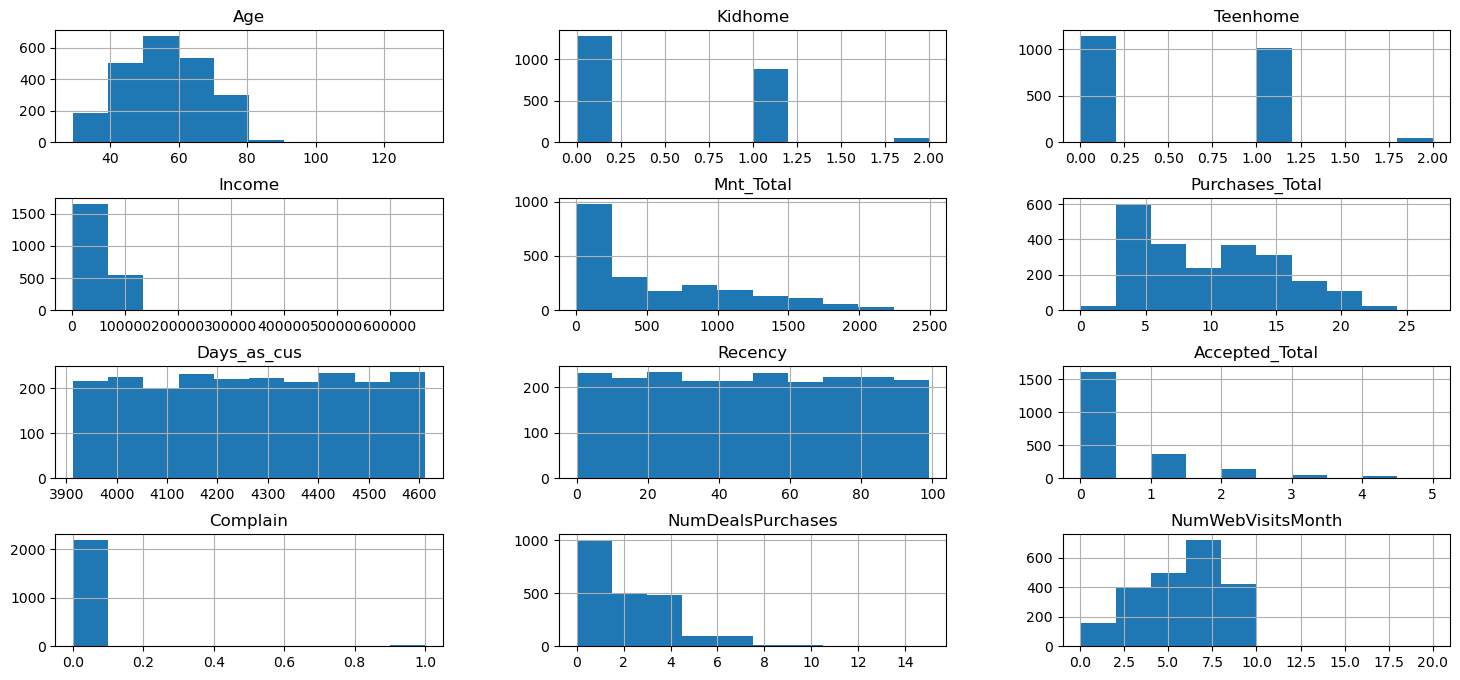

In [ ]:
df.hist(column = ['Age', 'Kidhome', 'Teenhome', 'Income', 'Mnt_Total', 'Purchases_Total', 'Days_as_cus', 'Recency', 'Accepted_Total', 'Complain', 'NumDealsPurchases', 'NumWebVisitsMonth'], figsize=(18,8))
plt.subplots_adjust(hspace=0.5)


<Axes: >

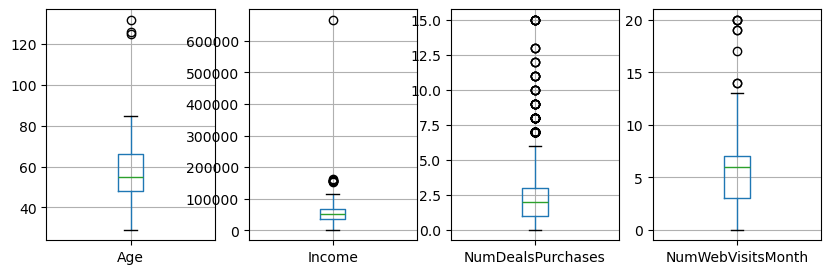

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(10,3))

df.boxplot(column=['Age'], ax=ax[0])
df.boxplot(column=['Income'], ax=ax[1])
df.boxplot(column=['NumDealsPurchases'], ax=ax[2])
df.boxplot(column=['NumWebVisitsMonth'], ax=ax[3])

### Выводы:
1. Переменные Age, Income, NumDealsPurchases и NumWebVisitsMonth имеют существенные выбросы. Для большей достоверности результатов дальнейших вычислений необходимо удалить их из рабочей табилцы 

In [ ]:
# Создаем отдельную таблицу, содержащую выбросы, чтобы при необходимости можно было включить данные обратно в рабочую таблицу

df_outliers = df
clear_df = df_outliers[0:0]

for column in df_outliers.loc[:, ['Age', 'Income', 'NumDealsPurchases', 'NumWebVisitsMonth']]:
    Q1 = df_outliers[column].quantile(0.25)
    Q3 = df_outliers[column].quantile(0.75)
    IQR = Q3 - Q1    
    clear_df = pd.concat([clear_df, df_outliers[df_outliers[column] > (Q3 + 1.5*IQR)]])
    

df_outliers = clear_df
df_outliers.head()

,ID,Age,Days_as_cus,Mnt_Total,Accepted_Total,Purchases_Total,Children_Total,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
181,7829,125,4189,40,0,4,1,2n Cycle,Divorced,36640.0,1,0,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,3,11,0
228,11004,132,3956,20,0,3,1,2n Cycle,Single,60182.0,0,1,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,3,11,0
326,1150,126,4189,1629,1,8,0,PhD,Together,83532.0,0,0,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,3,11,0
153,8475,52,4033,1607,0,0,1,PhD,Married,157243.0,0,1,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,3,11,0
604,1503,49,4304,105,0,1,2,PhD,Together,162397.0,1,1,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0


In [ ]:
# исключаем из рабочей таблицы наблюдения с выбросами

for column in df.loc[:, ['Age', 'Income', 'NumDealsPurchases', 'NumWebVisitsMonth']]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    new_df = df[df[column] <= (Q3 + 1.5*IQR)]
    df = new_df

df

,ID,Age,Days_as_cus,Mnt_Total,Accepted_Total,Purchases_Total,Children_Total,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,68,4576,1529,1,12,0,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,71,4026,21,0,3,2,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,60,4225,734,0,18,0,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,41,4052,48,0,6,1,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,44,4074,407,0,11,1,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,8372,51,4276,21,0,3,1,Graduation,Married,34421.0,1,0,81,3,3,7,6,2,9,1,1,0,2,7,0,0,0,0,0,0,3,11,0
2211,10870,58,4294,1094,0,13,1,Graduation,Married,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2213,7270,44,4068,1217,1,15,0,Graduation,Divorced,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2214,8235,69,4069,782,0,16,1,Master,Together,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


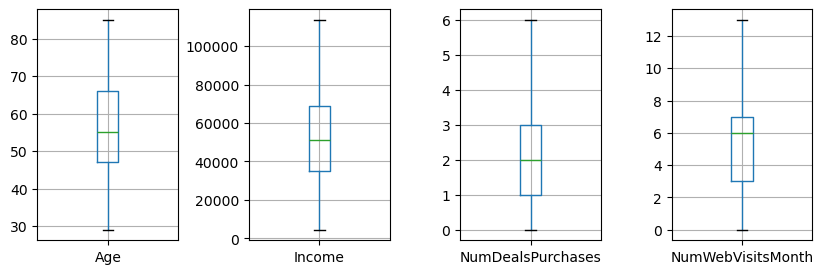

In [ ]:
# проверка отсутствия выбросов

fig, ax = plt.subplots(1,4, figsize=(10,3))

df.boxplot(column=['Age'], ax=ax[0])
df.boxplot(column=['Income'], ax=ax[1])
df.boxplot(column=['NumDealsPurchases'], ax=ax[2])
df.boxplot(column=['NumWebVisitsMonth'], ax=ax[3])
plt.subplots_adjust(wspace=0.5)

## Анализ социально-демографического профиля клиентов

In [ ]:
# Построение столбчатых диаграмм по переменным семейного статуса и уровня образования

fig, ax = plt.subplots(1,2, figsize=(15,3))
sns.countplot(df['Marital_Status'], ax=ax[0])
sns.countplot(df['Education'], ax=ax[1])

plt.subplots_adjust(wspace=0.3)
plt.show()

NameError: name 'plt' is not defined

### Выводы:
1. Семейное положение: В столбце, отражающем семейный статус, присутствуют уникальные формулировки, введенные покупателями вручную. Данные варианты по своей сути относятся к категории "не состоящие в браке". Для упрощения анализа предлагается объединить их с основным значением "Одинокий / холостяк".
2. Уровень образования: Обнаружено дублирование понятий: часть записей содержит значение "Master", тогда как другая часть — "2n Cycle". Оба термина обозначают наличие дипломов, сопоставимых со степенью магистра. В целях единообразия классификации рекомендуется привести все подобные записи к единому значению "Master".



In [ ]:
# Замена нестандартных семейных статусов на "Single" и статуса образования '2n Cycle' на 'Master'

df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')
df['Education'] = df['Education'].replace('2n Cycle', 'Master')

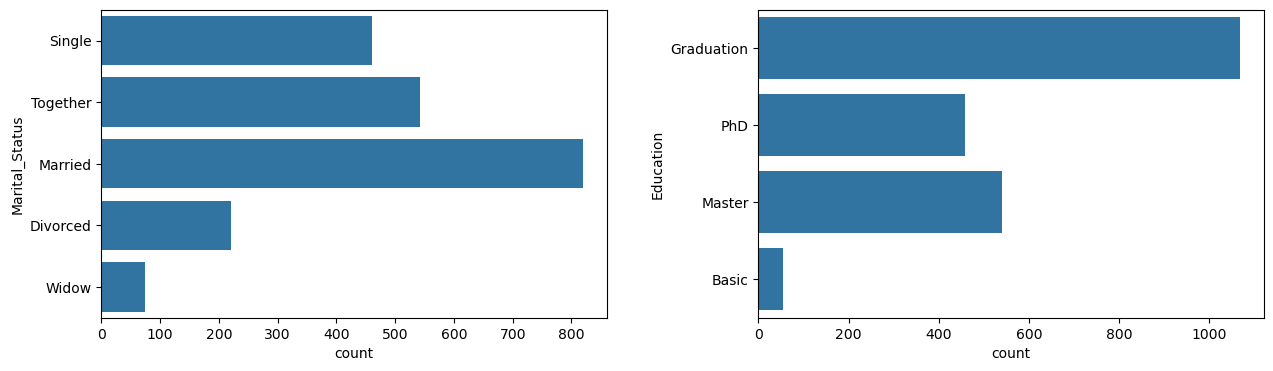

In [ ]:
# Обновленные графики 

fig, ax = plt.subplots(1,2, figsize=(15,4))
sns.countplot(df['Marital_Status'], ax=ax[0])
sns.countplot(df['Education'], ax=ax[1])

plt.subplots_adjust(wspace=0.3)
plt.show()

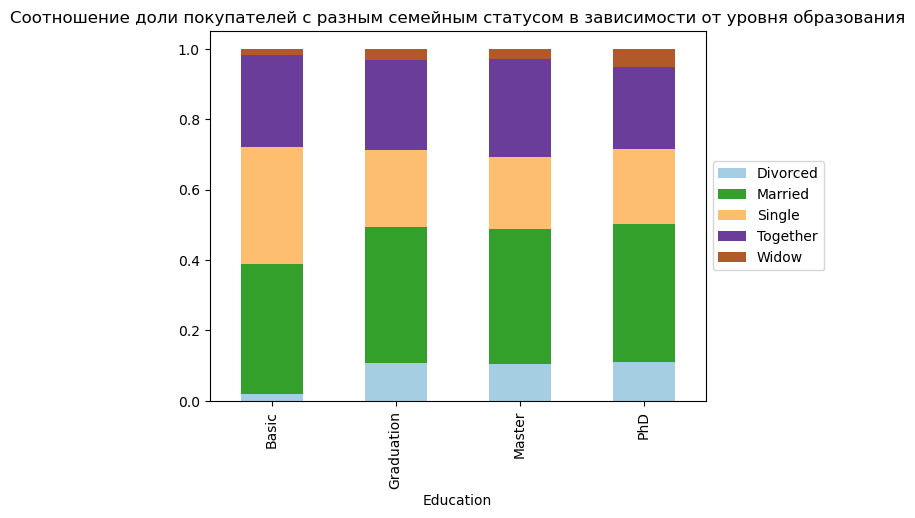

In [ ]:
# Создание графика на основании сводной таблицы Уровень образования*Семейный статус

df_plot = df.groupby(['Marital_Status', 'Education']).size().reset_index().pivot(columns='Marital_Status', index='Education', values=0) # создание сводной табилцы для построения графика
df_plot.apply(lambda x: x/x.sum(), axis=1).plot(kind='bar', stacked=True,  colormap='Paired', title='Соотношение доли покупателей с разным семейным статусом в зависимости от уровня образования')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

## Ключевые вопросы исследования:
# Маркетинговая эффективность
1. Какие из проведенных рекламных кампаний продемонстрировали наибольший отклик со стороны покупателей?
2. Существует ли взаимосвязь между лояльностью к рекламным предложениям (количество принятых кампаний) и такими характеристиками клиента, как его совокупные расходы в магазине и уровень дохода?
3. Наблюдается ли зависимость между объемом покупок, совершенных по дисконтным предложениям, и общей суммой трат клиента?
# Финансовые показатели
1. Какова общая выручка магазина за анализируемый период? Каков средний чек (средняя сумма трат) одного покупателя??
2. Как распределяется потребительская корзина между основными продуктовыми категориями (мясо, рыба, вино, сладости, фрукты, золото)? Какие категории приносят наибольший доход?
# Каналы продаж
1. В каком канале продаж фиксируется большее количество покупок — в традиционном офлайн-магазине или через интернет-платформу?
2. Где покупатели оставляют большую сумму денег: при личном посещении торговой точки или при оформлении заказов онлайн?


## Какие рекламные компании получили больше одобрения?

In [ ]:
at_all = df['ID'].count()

Percent_Accepted = pd.DataFrame({'Compain': ['Cmp1', 'Cmp2', 'Cmp3', 'Cmp4', 'Cmp5', 'LasCmp'],
                                 'Percentage_of_acception': [df['AcceptedCmp1'].sum()/at_all*100, df['AcceptedCmp2'].sum()/at_all*100, df['AcceptedCmp3'].sum()/at_all*100, df['AcceptedCmp4'].sum()/at_all*100, df['AcceptedCmp5'].sum()/at_all*100, df['Response'].sum()/at_all*100]})
Percent_Accepted 

,Compain,Percentage_of_acception
0,Cmp1,6.562795
1,Cmp2,1.369216
2,Cmp3,7.554297
3,Cmp4,7.271010
4,Cmp5,7.554297
5,LasCmp,14.872521


### Вывод:

Последняя рекламная кампания оказалась вдвое успешнее, чем три предыдущие со средними показателями, и в 15 раз успешнее, чем вторая кампания. Столь существенный разрыв может быть связан с накопленным опытом, изменением подхода к коммуникации или более точным попаданием в целевую аудиторию. Данный факт требует дополнительного изучения для тиражирования успешных практик в будущем.

## 

## Коррелируют ли количество откликов на рекламные компании с общими тратами в магазине и с доходом покупателей?
## Коррелируют ли количество покупок сделанных со скидкой с общими тратами в магазине?

Для начала построим хитмап для общей оценки связи между показателями

<Axes: >

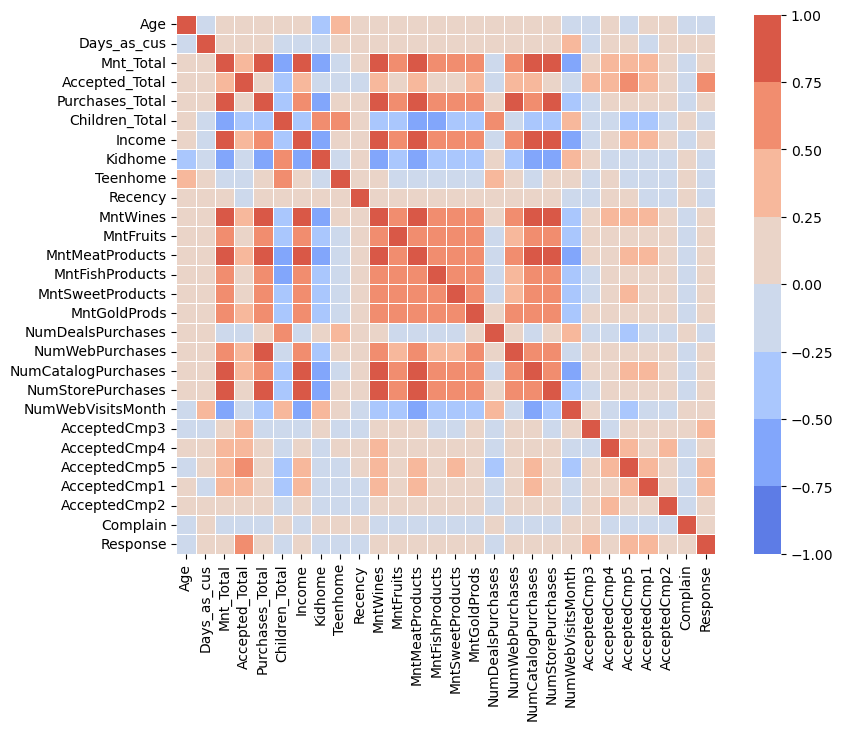

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(df.drop(['ID', 'Z_Revenue', 'Z_CostContact'], axis=1).corr(numeric_only=True, method='spearman'), 
            cmap=sns.color_palette("coolwarm", n_colors=8),
            vmin=-1,
            vmax=1, 
            square=True,
            linewidths=0.5
            )

Для ответа на вышеприведенные вопросы проведем корреляционный анализ с использованием критерия Спирмена

In [ ]:
res1 = stats.spearmanr(df['Accepted_Total'], df['Mnt_Total'])
print(f'Взаимосвязь количества откликов на рекламные компании и общих трат покупателем\nКоэффициент r-Спирмена = {res1.statistic}\nУровень значимости = {res1.pvalue.round(3)}')

print()

res2 = stats.spearmanr(df['Accepted_Total'], df['Income'])
print(f'Взаимосвязь количества откликов на рекламные компании и дохода у покупателя\nКоэффициент r-Спирмена = {res2.statistic}\nУровень значимости = {res2.pvalue.round(3)}')

print()

res3 = stats.spearmanr(df['NumDealsPurchases'], df['Mnt_Total'])
print(f'Взаимосвязь количества покупок, сделанных со скидкой, и общих трат покупателей\nКоэффициент r-Спирмена = {res3.statistic}\nУровень значимости = {res3.pvalue.round(3)}')



Взаимосвязь количества откликов на рекламные компании и общих трат покупателем
Коэффициент r-Спирмена = 0.3840108251500316
Уровень значимости = 0.0

Взаимосвязь количества откликов на рекламные компании и дохода у покупателя
Коэффициент r-Спирмена = 0.32285395651911863
Уровень значимости = 0.0

Взаимосвязь количества покупок, сделанных со скидкой, и общих трат покупателей
Коэффициент r-Спирмена = -0.047166960823675726
Уровень значимости = 0.03


### Выводы: 

1. Связь откликов на рекламу с доходами и тратами: Чем чаще покупатель участвует в рекламных кампаниях, тем выше его доход и общая сумма покупок. Связь статистически значимая (p < 0.001), но слабая или умеренная (коэффициенты 0.3 и 0.4). Причинно-следственную связь определить нельзя.

К сожалению, корреляционный анализ не позволяет нам судить о причино-следственных связях, поэтому ответ на вопрос о том, что за чем следует, остается открытым.

2. Связь покупок по скидке с общими тратами: Статистически значимой связи не обнаружено. Коэффициент корреляции близок к нулю (-0.05), p-value на границе допустимого (0.03). Влияние скидок на общий объем трат практически отсутствует.

## 

## Каков общий доход магазина за приведенное время? 

## Сколько в среднем потратим каждый покупатель за приведенное время?

In [ ]:
print(f'Общий доход магазина = {df['Mnt_Total'].sum()}$')
print()
print(f'В среднем каждый покупатель потратил примерно {df['Mnt_Total'].mean().round(2)}$')

Общий доход магазина = 1188623$

В среднем каждый покупатель потратил примерно 561.2$


## 

## Как распределяются траты покупателей между различными категориями продуктов?

Так как распределение расходов не соответствует нормальному, использован критерий Краскела-Уоллиса (вместо ANOVA).

In [ ]:
res4 = stats.kruskal(df['MntFishProducts'], df['MntMeatProducts'], df['MntFruits'], df['MntSweetProducts'], df['MntWines'])
res4

KruskalResult(statistic=2728.8147458238623, pvalue=0.0)

Поскольку критерий Краскела-Уоллиса подтвердил наличие различий между категориями, был проведен post-hoc анализ с использованием критерия Данна для попарного сравнения групп.

In [ ]:
p_values = sp.posthoc_dunn([df['MntFishProducts'], df['MntMeatProducts'], df['MntFruits'], df['MntSweetProducts'], df['MntWines']])
print(p_values <0.05)

       1      2      3      4      5
1  False   True   True   True   True
2   True  False   True   True   True
3   True   True  False  False   True
4   True   True  False  False   True
5   True   True   True   True  False


Все группы, кроме 3 и 4 (категории "фрукты" и "сладости") имеют статистически значимые различия. Построим столбчатую диаграмму средних значений затрат на эти категории продуктов

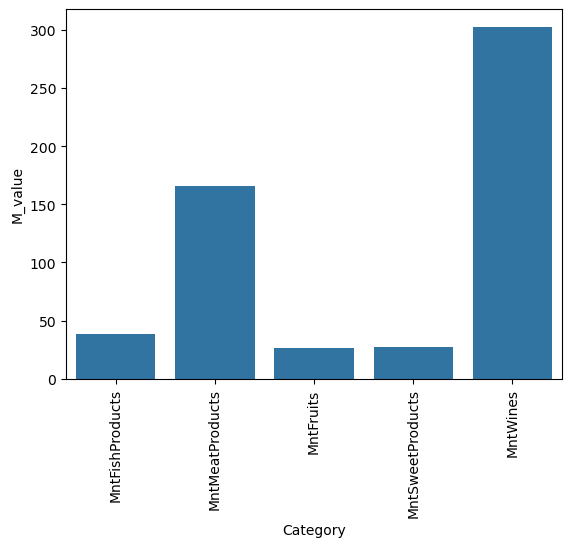

In [ ]:
mean_values = pd.DataFrame({'Category': ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines'],
                            'M_value': [df['MntFishProducts'].mean(), df['MntMeatProducts'].mean(), df['MntFruits'].mean(), df['MntSweetProducts'].mean(), df['MntWines'].mean()]})

sns.barplot(data=mean_values, x='Category', y='M_value')
plt.xticks(rotation=90)
plt.show()

Также построим круговую диаграмму на основе суммарного количества трат на каждую категорию продуктов

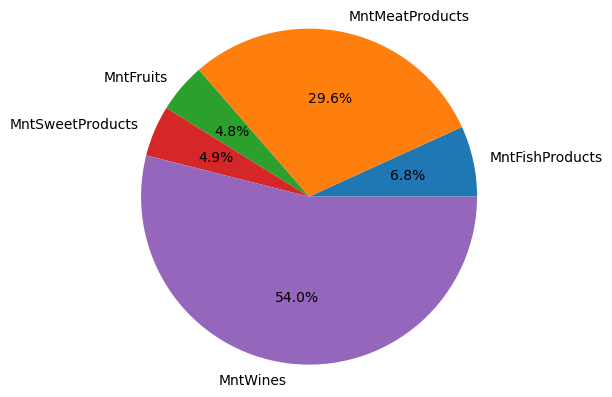

In [ ]:
total_values = pd.DataFrame({'Category': ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines'],
                            'Total_value': [df['MntFishProducts'].sum(), df['MntMeatProducts'].sum(), df['MntFruits'].sum(), df['MntSweetProducts'].sum(), df['MntWines'].sum()]})

plt.pie(total_values['Total_value'], labels=total_values['Category'], autopct='%1.1f%%')
plt.axis('equal')
plt.show()
#sns.barplot(data=total_values, x='Category', y='Total_value')
#plt.xticks(rotation=90)

### Выводы: 
1. Статистические различия: Покупатели тратят значимо разные суммы на разные категории товаров. Исключение — пара фрукты и сладости: различия в тратах между ними отсутствуют.
2. Лидеры по средним тратам:

        Вино — абсолютный лидер (~300$ на покупателя).

        Мясо — на втором месте, но с отставанием почти в 2 раза (~170$).
3. Вклад в выручку магазина:

        Винная продукция приносит более половины всей выручки — 54%.

        Фрукты и сладости — аутсайдеры, их совокупная доля в выручке составляет всего 10%.


### 

## Где совершается больше покупок: в физическом магазине или онлайн?

Для выявнения ответа на этот вопрос проведем сравнительный анализ с использованием критерия U-Манна-Уитни

In [ ]:
res5 = stats.mannwhitneyu(df['NumWebPurchases'], df['NumStorePurchases'])

print(f'Сравнение количества покупок сделанных в офлайн- и онлайн-магазине\nКоэффициент U-Манна-Уитни = {res5.statistic}\nУровень значимости = {res5.pvalue.round(3)}')
print()
print(f'Среднее количество покупок в онлайн-магазине = {df['NumWebPurchases'].mean().round(2)}\nСреднее количество покупок в офлайн-магазине = {df['NumStorePurchases'].mean().round(2)}')


Сравнение количества покупок сделанных в офлайн- и онлайн-магазине
Коэффициент U-Манна-Уитни = 1515070.0
Уровень значимости = 0.0

Среднее количество покупок в онлайн-магазине = 4.03
Среднее количество покупок в офлайн-магазине = 5.8


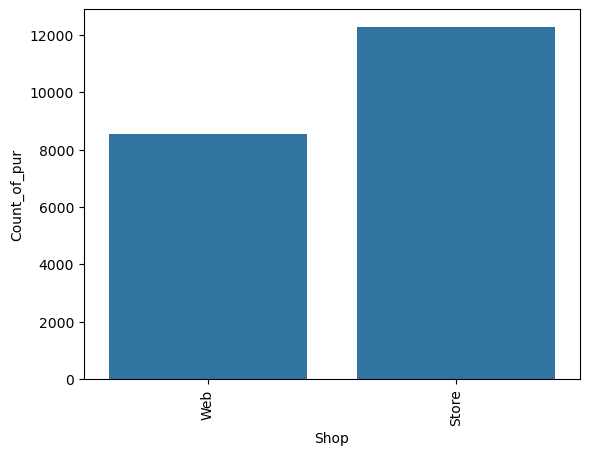

In [ ]:
total_purchases = pd.DataFrame({'Shop': ['Web', 'Store'],
                               'Count_of_pur': [df['NumWebPurchases'].sum(), df['NumStorePurchases'].sum()]})

sns.barplot(data=total_purchases, x='Shop', y='Count_of_pur')
plt.xticks(rotation=90)
plt.show()

### Выводы: 

1. Между группами обнаружены статистически значимые различия, соответственно, покупок в офлайн магазине делается больше, чем на вебсайте
2. За время сбора имеющихся данных в физическом магазине было совершено более 12000 покупок, а онлайн - около 8500. Таким образом в офлайн-магазине совершается практически в 1,5 раза больше покупок.

## 

## На какой площадке покупатели тратят больше денег: в физическом магазине или онлайн?

К сожалению, на основании имеющихся данных узнать ответ на данный вопрос невозможно, так как мы не имеем информации и том, сколько с общем каждый покупатель тратил в каждом из магазинов. 

Однако можно сделать грубую косвенную оценку доходности от магазинов посредством разделения покупателей на две группы: тех, кто делал больше покупок онлайн, и тех, кто делал больше покупок офлайн. 

In [ ]:
res6 = stats.mannwhitneyu(df['Mnt_Total'][df['NumWebPurchases'] < df['NumStorePurchases']], df['Mnt_Total'][df['NumWebPurchases'] > df['NumStorePurchases']])

print(f'Сравнение общих затрат покупателей в зависимости от того, в каком магазине они совершали больше покупок: офлайн и онлайн\nКоэффициент U-Манна-Уитни = {res6.statistic}\nУровень значимости = {res6.pvalue.round(3)}')
print()
print(f'Средние затраты покупателей, совершивших больше покупок на вебсайте = {df['Mnt_Total'][df['NumWebPurchases'] > df['NumStorePurchases']].mean().round(2)}\nСредние затраты покупателей, совершивших больше покупок в физическом магазине = {df['Mnt_Total'][df['NumWebPurchases'] < df['NumStorePurchases']].mean().round(2)}')


Сравнение общих затрат покупателей в зависимости от того, в каком магазине они совершали больше покупок: офлайн и онлайн
Коэффициент U-Манна-Уитни = 191186.5
Уровень значимости = 0.0

Средние затраты покупателей, совершивших больше покупок на вебсайте = 678.83
Средние затраты покупателей, совершивших больше покупок в физическом магазине = 551.55


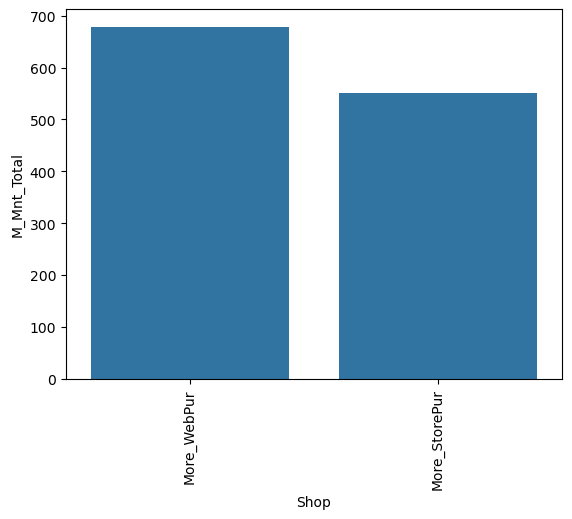

In [ ]:
total_amount = pd.DataFrame({'Shop': ['More_WebPur', 'More_StorePur'],
                      'M_Mnt_Total': [df['Mnt_Total'][df['NumWebPurchases'] > df['NumStorePurchases']].mean(), df['Mnt_Total'][df['NumWebPurchases'] < df['NumStorePurchases']].mean()]})

sns.barplot(data=total_amount, x='Shop', y='M_Mnt_Total')
plt.xticks(rotation=90)
plt.show()

Таким образом, в среднем покупатели, совершаюшие покупки онлайн в среднем тратят 679$, что статистически значимо больше затрат покупателей, закупающиеся преимущественно в офлайн-магазинах (552$).

Построим диаграмму суммарных трат покупателей внутри этих двух групп.

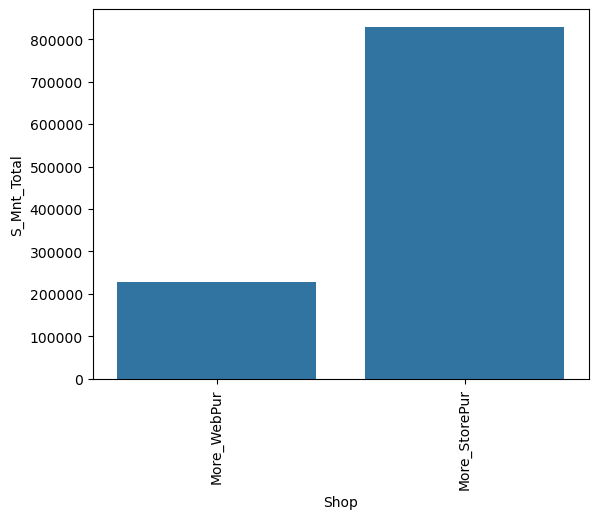

In [ ]:
total_amount = pd.DataFrame({'Shop': ['More_WebPur', 'More_StorePur'],
                      'S_Mnt_Total': [df['Mnt_Total'][df['NumWebPurchases'] > df['NumStorePurchases']].sum(), df['Mnt_Total'][df['NumWebPurchases'] < df['NumStorePurchases']].sum()]})

sns.barplot(data=total_amount, x='Shop', y='S_Mnt_Total')
plt.xticks(rotation=90)
plt.show()

При суммировании общих затрат получается, что покупатели, совершающие больше покупок в офлайн-магазине, тратят значительно больше, чем покупатели заказывающие товары онлайн. 

Возможно, это связано с распределением покупателей по показателю общих трат внутри каждой из групп. Для выяснения построим гистограммы.

<Axes: >

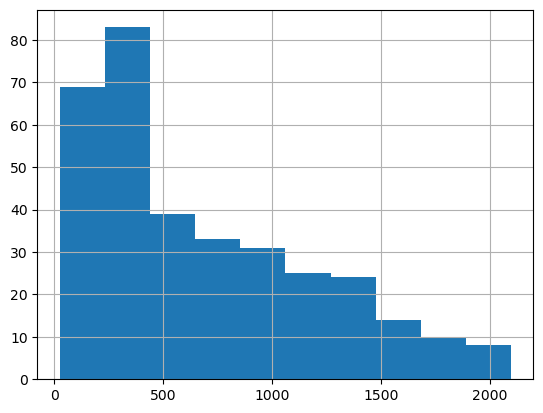

In [ ]:
df['Mnt_Total'][df['NumWebPurchases'] > df['NumStorePurchases']].hist()

<Axes: >

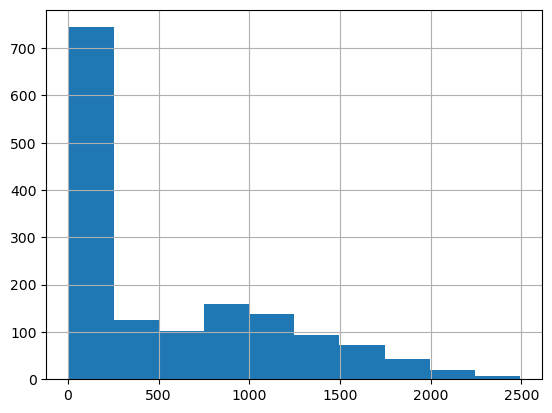

In [ ]:
df['Mnt_Total'][df['NumWebPurchases'] < df['NumStorePurchases']].hist()

### Выводы:
1. Действительно, из графиков видно, что среди покупателей, закупающихся преимущественно офлайн, присутствует много лиц, имеющих очень маленькие затраты (<250$), что влияет на величину среднего арифметического значения (средних затрат), уменьшая его.
2. Тем не менее, это не исключает того факта, что суммарные общие затраты больше именно у покупателей, совершающих больше офлайн-покупок.
